# Caregiver Cluster Analysis for the Autism Acceptability Study

Alright so this notebook implements the complete, reproducible clustering workflow that we discussed for the caregiver survey using synthetic data for now, which is actually shaped to the REDCap instrument.

## Notebook goals (Do edit or add more stuff so that we can make sure all the things are covered)
- Build a working analysis pipeline from raw survey-style responses to interpretable parent profiles.
- Preserve the study logic: TFA constructs, Schwartz values, demographics, and autism knowledge scoring.
- Show the theory, formulas, and statistical validation needed to defend the clustering solution.
- Produce figures and tables that can be adapted later to the real REDCap export.

## Expected outputs
- A cleaned analytic dataset with reverse-coded and recoded clustering features.
- Elbow and silhouette diagnostics for choosing K.
- A final K-means model with named cluster profiles.
- PCA, radar, and profile comparison visualizations.
- ANOVA, Kruskal-Wallis, chi-square, and predictive follow-up diagnostics.

## Theory, Measurement, and Modeling Decisions

Please do correct me if I am wrong in understanding anything or going in the wrong direction for the approach and logic for the cluster analysis.

### What cluster analysis does in this study
Cluster analysis groups caregivers who answered the acceptability survey in similar ways, without using outcome labels during model fitting. Well, in plain language, we are asking whether there are recurring response patterns such as broadly supportive parents, selective parents who prefer non-invasive modalities, or skeptical parents who anticipate regret or burden.

### Why K-means is an appropriate first model
K-means is a strong first-pass method here because the core TFA items behave like numeric survey scales and the output is easy to explain to a mixed research audience.

### Core formulas

Euclidean distance between two caregivers x and y across p features:

$$
d(x, y) = \sqrt{\sum_{j=1}^{p}(x_j - y_j)^2}
$$

Standardization of each feature before clustering:

$$
z = \frac{x - \mu}{\sigma}
$$

Cluster centroid for cluster k with n_k caregivers:

$$
\mu_k = \frac{1}{n_k}\sum_{i \in C_k} x_i
$$

Inertia or within-cluster sum of squares:

$$
\mathrm{WCSS} = \sum_{k=1}^{K}\sum_{i \in C_k}\lVert x_i - \mu_k \rVert^2
$$

Silhouette score for one caregiver:

$$
s = \frac{b-a}{\max(a,b)}
$$

where a is the average distance to the caregiver's own cluster and b is the average distance to the nearest competing cluster.

ANOVA F-statistic for post-cluster mean differences:

$$
F = \frac{\text{between-group variance}}{\text{within-group variance}}
$$

Chi-square test for categorical profile differences:

$$
\chi^2 = \sum \frac{(O - E)^2}{E}
$$

### Methodological choices used below
- Demographic variables are excluded from clustering and used only for post hoc profiling and prediction.
- Ordinal items with inverse meaning are recoded so higher values always indicate greater acceptability or support.
- The regret item is reverse scored for clustering because high regret implies lower acceptability.
- Missing values are imputed with medians in the synthetic example, while the markdown notes where MICE would be more appropriate for the real dataset.
- Cluster naming is derived from centroid patterns instead of trusting arbitrary numeric labels from the algorithm.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from scipy.stats import chi2_contingency, f_oneway, kruskal
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk', font_scale=0.85)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

n_total = 135

tfa_slider_vars = [
    'tfa_mri', 'tfa_eeg', 'tfa_blood', 'tfa_video', 'tfa_saliva',
    'tfa_observe', 'tfa_believe_positive', 'tfa_interact_positive',
    'tfa_regret', 'tfa_gain_vs_loss'
]

value_vars = [
    'conformity_val', 'tradition_val', 'benevolence_val',
    'universalism_val', 'self_direction_val', 'security_val',
    'ethicality_val'
]

raw_ordinal_vars = ['tfa_scan_mine', 'tfa_free_screen']
knowledge_raw_vars = ['tfa_behavior_age', 'tfa_autistic_us', 'tfa_mult_kids_odds']
knowledge_score_var = 'autism_knowledge_score'

cluster_feature_cols = [
    'tfa_mri', 'tfa_eeg', 'tfa_blood', 'tfa_video', 'tfa_saliva', 'tfa_observe',
    'tfa_believe_positive', 'tfa_interact_positive', 'tfa_gain_vs_loss',
    'tfa_regret_reverse', 'tfa_scan_mine_recode', 'tfa_free_screen_recode',
    'conformity_val', 'tradition_val', 'benevolence_val', 'universalism_val',
    'self_direction_val', 'security_val', 'ethicality_val', knowledge_score_var,
]

profile_only_cols = ['lived_experience', 'race', 'income', 'education', 'area']

cluster_palette = {
    'Trusting Pragmatists': '#1f77b4',
    'Modality-Sensitive Anxious': '#ff7f0e',
    'Burden-Averse Skeptics': '#d62728',
    'Informed Supporters': '#2ca02c',
}

print(f'Configured notebook environment with {len(cluster_feature_cols)} clustering features.')

Configured notebook environment with 20 clustering features.


### Setup analysis
This setup cell establishes the exact feature groups used later in the notebook. But I gotta point out this one important methodological correction appears here i.e., the clustering feature set uses reverse-coded regret and recoded ordinal willingness and moral-rightness items so that larger values consistently mean more screening support. Without that alignment, Euclidean distance would mix opposite directions and distort the cluster geometry.

In [2]:
def clipped_normal(mean, sd, size, low, high):
    return np.clip(rng.normal(mean, sd, size), low, high)


def choose_from_probs(options, probs, size):
    return rng.choice(options, size=size, p=probs)


def generate_scored_item(size, correct_option, all_options, correct_prob):
    responses = []
    distractors = [option for option in all_options if option != correct_option]
    for is_correct in rng.random(size) < correct_prob:
        if is_correct:
            responses.append(correct_option)
        else:
            responses.append(rng.choice(distractors))
    return np.array(responses)


group_specs = {
    'Trusting Pragmatists': {
        'n': 38,
        'tfa_means': [6.1, 6.0, 5.7, 6.4, 6.5, 6.2, 5.8, 5.3, 2.2, 5.7],
        'value_means': [3.8, 3.5, 4.7, 4.6, 4.0, 4.4, 4.3],
        'scan_probs': [0.45, 0.35, 0.12, 0.05, 0.02, 0.01],
        'free_screen_probs': [0.50, 0.30, 0.12, 0.06, 0.02],
        'knowledge_correct_probs': [0.72, 0.74, 0.70],
        'lived_experience_probs': [0.45, 0.55],
        'race_probs': [0.60, 0.18, 0.14, 0.08],
        'income_probs': [0.15, 0.25, 0.35, 0.25],
        'education_probs': [0.10, 0.25, 0.35, 0.30],
        'area_probs': [0.35, 0.45, 0.20],
    },
    'Modality-Sensitive Anxious': {
        'n': 35,
        'tfa_means': [3.0, 3.5, 2.9, 5.9, 6.1, 5.6, 4.6, 4.2, 4.3, 4.1],
        'value_means': [3.5, 3.2, 4.2, 4.0, 4.1, 4.5, 4.0],
        'scan_probs': [0.20, 0.30, 0.25, 0.15, 0.07, 0.03],
        'free_screen_probs': [0.18, 0.28, 0.30, 0.18, 0.06],
        'knowledge_correct_probs': [0.55, 0.52, 0.58],
        'lived_experience_probs': [0.35, 0.65],
        'race_probs': [0.50, 0.22, 0.18, 0.10],
        'income_probs': [0.18, 0.34, 0.30, 0.18],
        'education_probs': [0.16, 0.34, 0.30, 0.20],
        'area_probs': [0.45, 0.38, 0.17],
    },
    'Burden-Averse Skeptics': {
        'n': 30,
        'tfa_means': [2.0, 2.4, 2.2, 3.3, 3.7, 3.0, 2.8, 2.5, 6.1, 2.4],
        'value_means': [4.4, 4.2, 3.9, 3.6, 2.9, 5.0, 4.6],
        'scan_probs': [0.04, 0.08, 0.15, 0.28, 0.28, 0.17],
        'free_screen_probs': [0.05, 0.08, 0.17, 0.34, 0.36],
        'knowledge_correct_probs': [0.32, 0.28, 0.25],
        'lived_experience_probs': [0.55, 0.45],
        'race_probs': [0.35, 0.40, 0.15, 0.10],
        'income_probs': [0.34, 0.34, 0.22, 0.10],
        'education_probs': [0.30, 0.36, 0.22, 0.12],
        'area_probs': [0.30, 0.28, 0.42],
    },
    'Informed Supporters': {
        'n': 32,
        'tfa_means': [5.3, 5.2, 4.8, 6.0, 6.1, 6.0, 6.0, 5.8, 2.4, 5.8],
        'value_means': [3.6, 3.0, 4.8, 4.9, 4.8, 4.1, 4.7],
        'scan_probs': [0.42, 0.34, 0.15, 0.05, 0.03, 0.01],
        'free_screen_probs': [0.44, 0.34, 0.14, 0.06, 0.02],
        'knowledge_correct_probs': [0.85, 0.82, 0.84],
        'lived_experience_probs': [0.65, 0.35],
        'race_probs': [0.52, 0.18, 0.20, 0.10],
        'income_probs': [0.12, 0.26, 0.34, 0.28],
        'education_probs': [0.08, 0.22, 0.34, 0.36],
        'area_probs': [0.40, 0.42, 0.18],
    },
}

frames = []
for profile_name, spec in group_specs.items():
    size = spec['n']
    block = pd.DataFrame({
        var: clipped_normal(mean, 0.75, size, 1, 7)
        for var, mean in zip(tfa_slider_vars, spec['tfa_means'])
    })

    for var, mean in zip(value_vars, spec['value_means']):
        block[var] = clipped_normal(mean, 0.65, size, 1, 6)

    block['tfa_scan_mine'] = choose_from_probs(np.arange(1, 7), spec['scan_probs'], size)
    block['tfa_free_screen'] = choose_from_probs(np.arange(1, 6), spec['free_screen_probs'], size)

    block['tfa_behavior_age'] = generate_scored_item(size, 3, [1, 2, 3, 4, 5, 6], spec['knowledge_correct_probs'][0])
    block['tfa_autistic_us'] = generate_scored_item(size, 2, [1, 2, 3, 4], spec['knowledge_correct_probs'][1])
    block['tfa_mult_kids_odds'] = generate_scored_item(size, 3, [1, 2, 3, 4, 5], spec['knowledge_correct_probs'][2])

    block['lived_experience'] = choose_from_probs(['ASD_parent', 'NT_parent'], spec['lived_experience_probs'], size)
    block['race'] = choose_from_probs(['White', 'Black', 'Hispanic', 'Other'], spec['race_probs'], size)
    block['income'] = choose_from_probs(['<30k', '30-60k', '60-100k', '>100k'], spec['income_probs'], size)
    block['education'] = choose_from_probs(['HS', 'Some college', 'Bachelor', 'Graduate'], spec['education_probs'], size)
    block['area'] = choose_from_probs(['Urban', 'Suburban', 'Rural'], spec['area_probs'], size)
    block['source_profile'] = profile_name

    frames.append(block)

df = pd.concat(frames, ignore_index=True)

print(f'Synthetic dataset shape: {df.shape}')
display(df.head())
display(df['source_profile'].value_counts().rename_axis('synthetic_profile').to_frame('n'))

Synthetic dataset shape: (135, 28)


,tfa_mri,tfa_eeg,tfa_blood,tfa_video,tfa_saliva,tfa_observe,tfa_believe_positive,tfa_interact_positive,tfa_regret,tfa_gain_vs_loss,conformity_val,tradition_val,benevolence_val,universalism_val,self_direction_val,security_val,ethicality_val,tfa_scan_mine,tfa_free_screen,tfa_behavior_age,tfa_autistic_us,tfa_mult_kids_odds,lived_experience,race,income,education,area,source_profile
0,6.328538,5.381639,5.379561,6.454097,5.243988,7.000000,5.160067,5.416572,2.154007,5.754025,3.870122,3.455060,5.399556,4.399363,3.708433,3.458717,3.204362,2,1,3,2,3,ASD_parent,Other,30-60k,Graduate,Suburban,Trusting Pragmatists
1,5.320012,6.487945,5.818905,6.002880,6.135269,6.065361,5.584462,5.563817,1.410326,6.010418,4.651208,4.379831,4.150320,5.208106,4.294017,4.355813,4.649722,6,5,1,2,3,NT_parent,White,>100k,Graduate,Suburban,Trusting Pragmatists
2,6.662838,6.557441,6.169193,6.574507,6.459663,5.912610,4.702418,5.339867,1.949158,6.912157,2.758531,3.559882,4.916496,3.409586,2.982257,4.570323,3.627700,2,2,2,2,3,NT_parent,White,>100k,Some college,Suburban,Trusting Pragmatists
3,6.805424,6.407366,5.467990,6.416389,7.000000,7.000000,5.356970,5.300063,3.175033,4.152571,2.986429,2.955691,4.683189,4.381855,4.414356,3.815198,4.452929,2,3,3,2,1,ASD_parent,White,>100k,Graduate,Suburban,Trusting Pragmatists
4,4.636724,5.500868,6.042581,7.000000,6.597706,5.369716,6.036704,4.758831,2.636991,5.256672,2.759169,3.113640,4.904040,3.305972,3.649799,4.523398,3.374573,1,3,3,2,3,NT_parent,White,60-100k,Bachelor,Rural,Trusting Pragmatists


,n
synthetic_profile,
Trusting Pragmatists,38
Modality-Sensitive Anxious,35
Informed Supporters,32
Burden-Averse Skeptics,30


### Synthetic design analysis
The synthetic dataset intentionally contains four latent caregiver profiles so that the notebook can demonstrate a defensible K = 4 solution end to end.

In [5]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

analysis_df = df.copy()

# Introduce synthetic missingness
for col, frac in {
    'tfa_blood': 0.10,
    'self_direction_val': 0.08,
    'tfa_free_screen': 0.07,
    'income': 0.15,
}.items():
    missing_idx = rng.choice(analysis_df.index, size=int(round(frac * len(analysis_df))), replace=False)
    analysis_df.loc[missing_idx, col] = np.nan

missing_before = (
    analysis_df.isna()
    .mean()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .rename('missing_rate')
    .to_frame()
)

# Scoring and Recoding
analysis_df['score_item1'] = (analysis_df['tfa_behavior_age'] == 3).astype(int)
analysis_df['score_item2'] = (analysis_df['tfa_autistic_us'] == 2).astype(int)
analysis_df['score_item3'] = (analysis_df['tfa_mult_kids_odds'] == 3).astype(int)
analysis_df[knowledge_score_var] = analysis_df[['score_item1', 'score_item2', 'score_item3']].sum(axis=1)

analysis_df['tfa_regret_reverse'] = 8 - analysis_df['tfa_regret']
analysis_df['tfa_scan_mine_recode'] = 7 - analysis_df['tfa_scan_mine']
analysis_df['tfa_free_screen_recode'] = 6 - analysis_df['tfa_free_screen']

# MICE Imputation for clustering features
# We use BayesianRidge as the estimator for the chained equations
mice_imputer = IterativeImputer(random_state=RANDOM_STATE, max_iter=10)
analysis_df[cluster_feature_cols] = mice_imputer.fit_transform(analysis_df[cluster_feature_cols])

feature_summary = analysis_df[cluster_feature_cols].describe().T[['mean', 'std', 'min', 'max']].round(2)
knowledge_score_table = (
    analysis_df[knowledge_score_var]
    .value_counts()
    .sort_index()
    .rename_axis('score')
    .to_frame('count')
)

duplicate_rows = int(analysis_df.duplicated().sum())

print(f'MICE imputation complete for {len(cluster_feature_cols)} features.')
print(f'Duplicate rows detected: {duplicate_rows}')
display(missing_before)
display(knowledge_score_table)
display(feature_summary.head(10))

MICE imputation complete for 20 features.
Duplicate rows detected: 0


,missing_rate
income,0.148148
tfa_blood,0.103704
self_direction_val,0.081481
tfa_free_screen,0.066667


,count
score,
0.0,17
1.0,32
2.0,48
3.0,38


,mean,std,min,max
tfa_mri,4.26,1.77,1.00,7.00
tfa_eeg,4.39,1.52,1.00,7.00
tfa_blood,3.88,1.53,1.00,6.67
tfa_video,5.41,1.33,1.94,7.00
tfa_saliva,5.69,1.12,3.09,7.00
tfa_observe,5.26,1.47,1.72,7.00
tfa_believe_positive,4.84,1.39,1.40,7.00
tfa_interact_positive,4.44,1.44,1.39,7.00
tfa_gain_vs_loss,4.69,1.55,1.00,7.00
tfa_regret_reverse,4.28,1.62,1.00,7.00


### Cleaning and scoring analysis
Alright, so I implemented the autism knowledge score exactly as three binary items summed to a total from 0 to 3. This also performs the recoding needed for clustering. For the real REDCap dataset, this is the point where a richer imputation strategy such as MICE can replace median imputation for sensitive or systematically missing variables. The notebook overall keeps demographics outside the clustering matrix so any association between cluster membership and race, income, education, or lived experience can be interpreted as a profile finding rather than a forced partitioning rule.

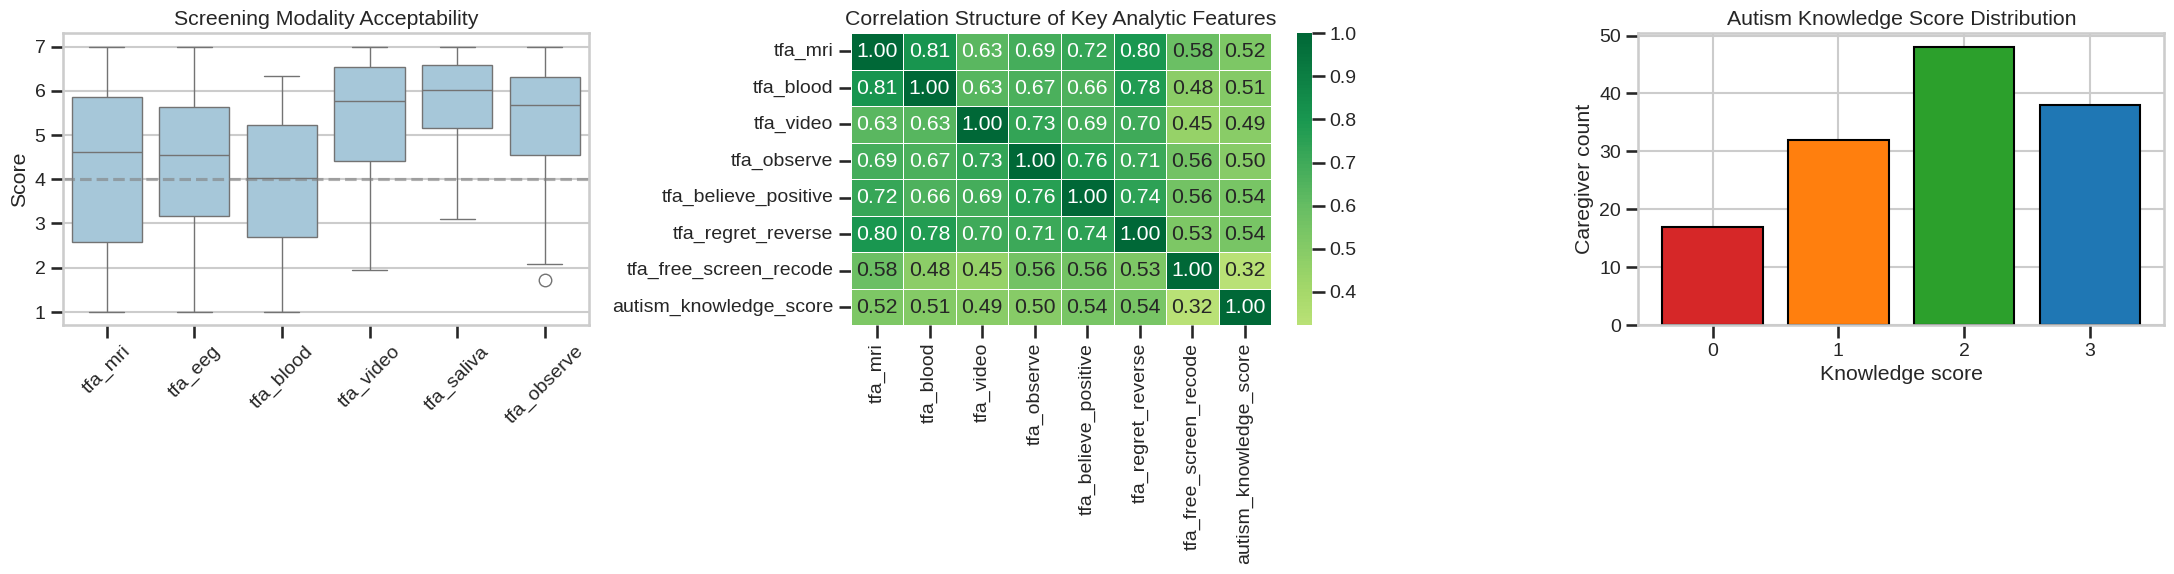

,tfa_mri,tfa_video,tfa_regret,autism_knowledge_score
source_profile,,,,
Burden-Averse Skeptics,2.09,3.36,5.92,0.73
Informed Supporters,5.42,5.93,2.56,2.47
Modality-Sensitive Anxious,3.06,5.74,4.40,1.69
Trusting Pragmatists,6.11,6.28,2.33,2.16


In [4]:
modality_cols = ['tfa_mri', 'tfa_eeg', 'tfa_blood', 'tfa_video', 'tfa_saliva', 'tfa_observe']
correlation_cols = [
    'tfa_mri', 'tfa_blood', 'tfa_video', 'tfa_observe',
    'tfa_believe_positive', 'tfa_regret_reverse',
    'tfa_free_screen_recode', knowledge_score_var,
]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

modality_long = analysis_df[modality_cols].melt(var_name='modality', value_name='score')
sns.boxplot(data=modality_long, x='modality', y='score', ax=axes[0], color='#9ecae1')
axes[0].set_title('Screening Modality Acceptability')
axes[0].set_xlabel('')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(4, linestyle='--', color='gray', alpha=0.6)

sns.heatmap(
    analysis_df[correlation_cols].corr(),
    cmap='RdYlGn', center=0, annot=True, fmt='.2f',
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title('Correlation Structure of Key Analytic Features')

knowledge_counts = (
    analysis_df[knowledge_score_var]
    .round()
    .astype(int)
    .value_counts()
    .reindex([0, 1, 2, 3], fill_value=0)
)
axes[2].bar(
    knowledge_counts.index.astype(str),
    knowledge_counts.values,
    color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'],
    edgecolor='black'
)
axes[2].set_title('Autism Knowledge Score Distribution')
axes[2].set_xlabel('Knowledge score')
axes[2].set_ylabel('Caregiver count')

plt.tight_layout()
plt.show()

eda_glimpse = (
    analysis_df.groupby('source_profile')[['tfa_mri', 'tfa_video', 'tfa_regret', knowledge_score_var]]
    .mean()
    .round(2)
)
display(eda_glimpse)

### EDA interpretation guide
The first plot shows how much each screening modality varies across caregivers. Large spread on MRI or blood measures usually signals disagreement about invasive procedures. The correlation heatmap helps identify whether acceptability variables move together strongly enough to define broad support or skepticism dimensions. The knowledge score plot is a quick sanity check that the three-item scoring rule produces a plausible distribution rather than collapsing at a single value.

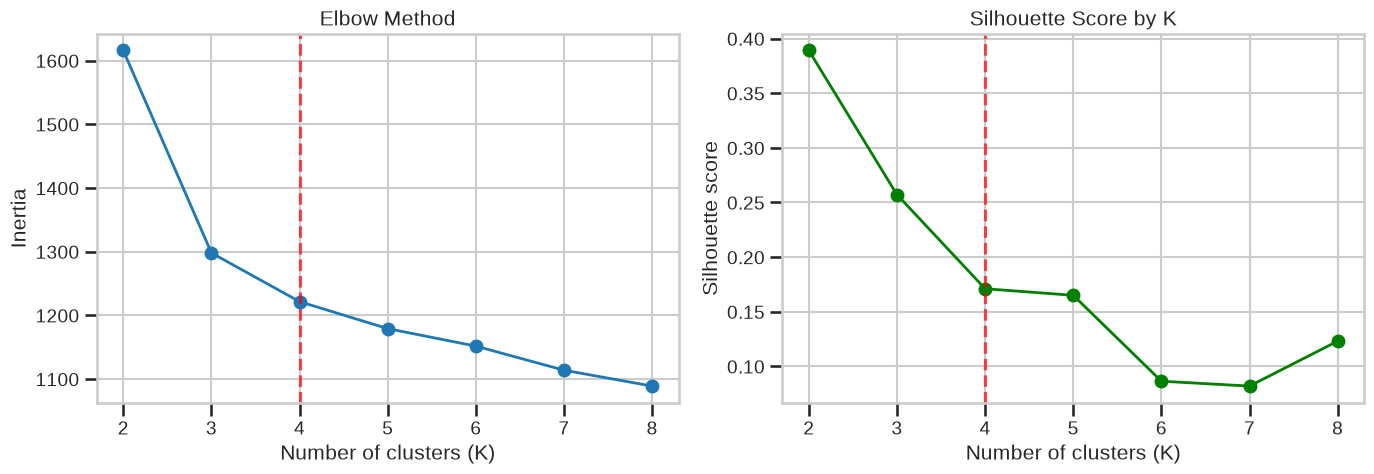

,k,inertia,silhouette_score
0,2,1615.8028,0.3891
1,3,1297.8777,0.2571
2,4,1221.3642,0.1710
3,5,1179.0196,0.1650
4,6,1151.4926,0.0864
5,7,1113.7015,0.0819
6,8,1088.7635,0.1231


Highest silhouette score suggests K = 2. Final domain-aligned choice: K = 4.


In [ ]:
X = analysis_df[cluster_feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_results = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25, max_iter=500)
    labels = model.fit_predict(X_scaled)
    k_results.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette_score': silhouette_score(X_scaled, labels),
    })

k_diagnostics = pd.DataFrame(k_results)
best_k_by_silhouette = int(k_diagnostics.loc[k_diagnostics['silhouette_score'].idxmax(), 'k'])
K_FINAL = 4

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_diagnostics['k'], k_diagnostics['inertia'], marker='o', linewidth=2)
axes[0].axvline(K_FINAL, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_diagnostics['k'], k_diagnostics['silhouette_score'], marker='o', linewidth=2, color='green')
axes[1].axvline(K_FINAL, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.show()

display(k_diagnostics.round(4))
print(f'Highest silhouette score suggests K = {best_k_by_silhouette}. Final domain-aligned choice: K = {K_FINAL}.')

### K-selection analysis
Now, I used both diagnostics together. The elbow plot shows when additional clusters stop reducing within-cluster spread in a meaningful way, while the silhouette plot measures how distinct the clusters remain. In real data, interpretability matters as much as the metric peak. If K = 3 and K = 4 are close by silhouette score, the more clinically meaningful solution can still be preferred if the profiles are easier to explain and act on.

In [ ]:
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=40, max_iter=500)
analysis_df['cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_profiles = analysis_df.groupby('cluster')[cluster_feature_cols].mean()
cluster_profiles['overall_acceptance'] = cluster_profiles[
    [
        'tfa_mri', 'tfa_eeg', 'tfa_blood', 'tfa_video', 'tfa_saliva', 'tfa_observe',
        'tfa_believe_positive', 'tfa_interact_positive', 'tfa_gain_vs_loss',
        'tfa_regret_reverse', 'tfa_scan_mine_recode', 'tfa_free_screen_recode',
    ]
].mean(axis=1)
cluster_profiles['invasive_acceptance'] = cluster_profiles[['tfa_mri', 'tfa_eeg', 'tfa_blood']].mean(axis=1)
cluster_profiles['noninvasive_acceptance'] = cluster_profiles[['tfa_video', 'tfa_saliva', 'tfa_observe']].mean(axis=1)
cluster_profiles['knowledge_mean'] = cluster_profiles[knowledge_score_var]
cluster_profiles['raw_regret_mean'] = analysis_df.groupby('cluster')['tfa_regret'].mean()

remaining = set(cluster_profiles.index)
cluster_name_map = {}

skeptic = (((7 - cluster_profiles['overall_acceptance']) + cluster_profiles['raw_regret_mean']).idxmax())
cluster_name_map[skeptic] = 'Burden-Averse Skeptics'
remaining.remove(skeptic)

trusting = cluster_profiles.loc[list(remaining), 'overall_acceptance'].idxmax()
cluster_name_map[trusting] = 'Trusting Pragmatists'
remaining.remove(trusting)

informed = cluster_profiles.loc[list(remaining), 'knowledge_mean'].idxmax()
cluster_name_map[informed] = 'Informed Supporters'
remaining.remove(informed)

modality_sensitive = list(remaining)[0]
cluster_name_map[modality_sensitive] = 'Modality-Sensitive Anxious'

analysis_df['cluster_name'] = analysis_df['cluster'].map(cluster_name_map)
cluster_order = [
    'Trusting Pragmatists',
    'Modality-Sensitive Anxious',
    'Burden-Averse Skeptics',
    'Informed Supporters',
]

cluster_profiles_named = cluster_profiles.copy()
cluster_profiles_named.index = cluster_profiles_named.index.map(cluster_name_map)
cluster_profiles_named = cluster_profiles_named.reindex(cluster_order)
cluster_profiles_named.index.name = 'cluster_name'

cluster_counts = analysis_df['cluster_name'].value_counts().reindex(cluster_order)
cluster_summary = cluster_profiles_named[
    ['overall_acceptance', 'invasive_acceptance', 'noninvasive_acceptance', 'knowledge_mean', 'raw_regret_mean']
].copy()
cluster_summary.insert(0, 'n', cluster_counts.values)
cluster_summary.insert(1, 'pct', (cluster_counts.values / len(analysis_df) * 100).round(1))

centroid_table = cluster_profiles_named[
    ['tfa_mri', 'tfa_blood', 'tfa_video', 'tfa_observe', 'tfa_believe_positive', 'tfa_regret_reverse', 'tfa_free_screen_recode', knowledge_score_var]
].round(2)

source_alignment = pd.crosstab(
    analysis_df['cluster_name'],
    analysis_df['source_profile'],
    normalize='index'
).reindex(cluster_order).round(2)

display(cluster_summary.round(2))
display(centroid_table)
display(source_alignment)

,n,pct,overall_acceptance,invasive_acceptance,noninvasive_acceptance,knowledge_mean,raw_regret_mean
cluster_name,,,,,,,
Trusting Pragmatists,33,24.4,5.73,5.82,6.26,2.15,2.24
Modality-Sensitive Anxious,35,25.9,4.21,3.25,5.75,1.69,4.40
Burden-Averse Skeptics,30,22.2,2.67,2.26,3.41,0.73,5.92
Informed Supporters,37,27.4,5.43,5.19,6.10,2.43,2.61


,tfa_mri,tfa_blood,tfa_video,tfa_observe,tfa_believe_positive,tfa_regret_reverse,tfa_free_screen_recode,autism_knowledge_score
cluster_name,,,,,,,,
Trusting Pragmatists,6.12,5.35,6.27,6.15,5.50,5.76,4.58,2.15
Modality-Sensitive Anxious,3.06,3.04,5.74,5.51,4.71,3.60,3.20,1.69
Burden-Averse Skeptics,2.09,2.20,3.36,2.93,2.75,2.08,2.10,0.73
Informed Supporters,5.52,4.86,5.99,6.10,6.06,5.39,3.73,2.43


source_profile,Burden-Averse Skeptics,Informed Supporters,Modality-Sensitive Anxious,Trusting Pragmatists
cluster_name,,,,
Trusting Pragmatists,0.0,0.09,0.0,0.91
Modality-Sensitive Anxious,0.0,0.00,1.0,0.00
Burden-Averse Skeptics,1.0,0.00,0.0,0.00
Informed Supporters,0.0,0.78,0.0,0.22


### Cluster interpretation analysis
So, numeric cluster labels from K-means are arbitrary, so this notebook names clusters only after inspecting the centroids. The naming logic first identifies the most skeptical cluster by low overall acceptance plus high raw regret, then identifies the most broadly supportive cluster, then uses autism knowledge to separate the remaining two. This avoids a common reporting mistake where label 0 or label 1 is treated as if it has a stable substantive meaning across runs.

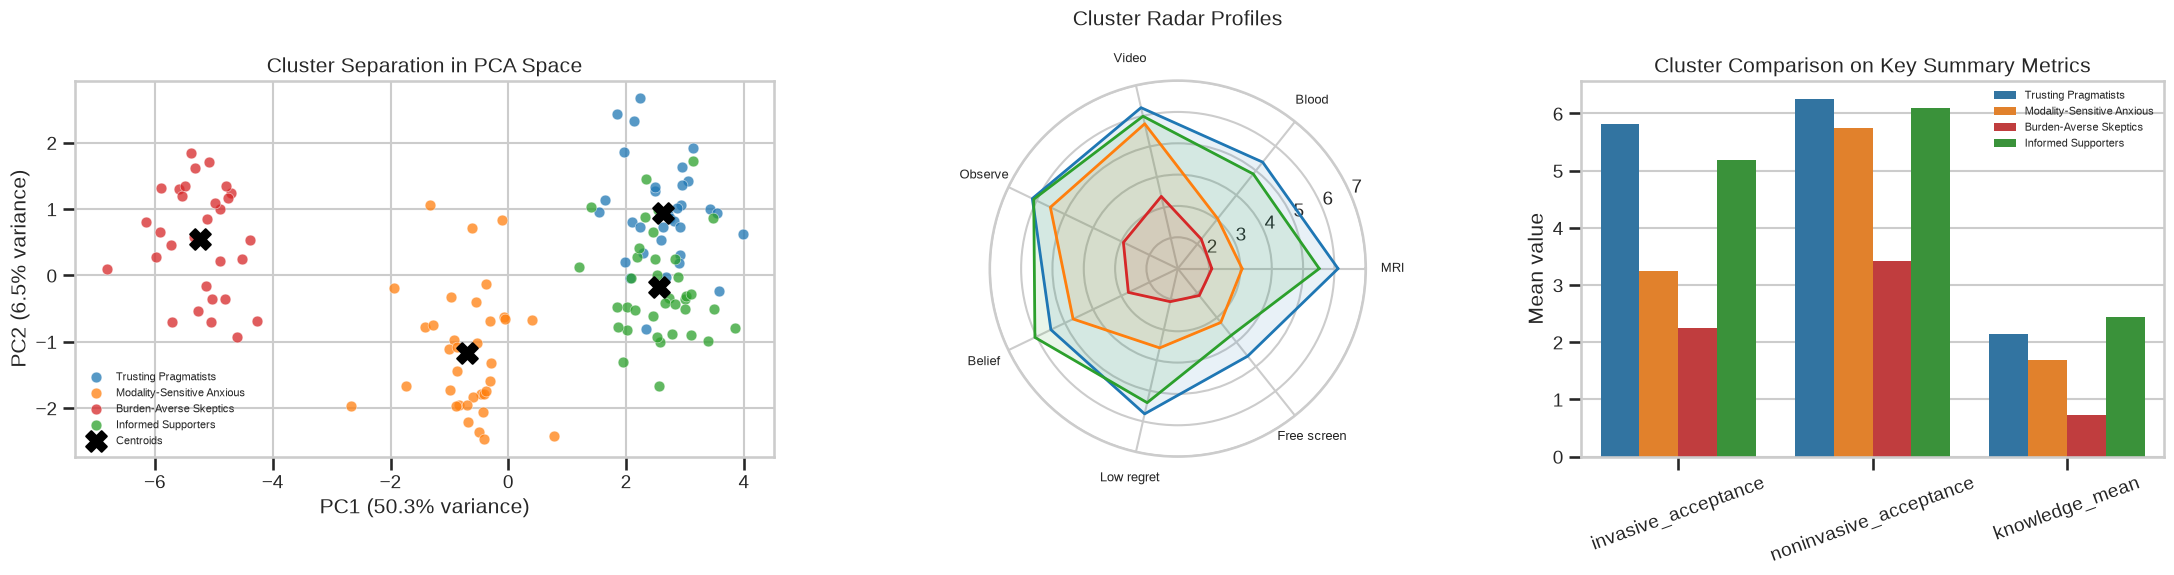

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
analysis_df['pca1'] = X_pca[:, 0]
analysis_df['pca2'] = X_pca[:, 1]

centers_pca = pca.transform(kmeans_final.cluster_centers_)
center_frame = pd.DataFrame(centers_pca, columns=['pca1', 'pca2'])
center_frame['cluster_name'] = [cluster_name_map[idx] for idx in range(K_FINAL)]

profile_plot = cluster_profiles_named.copy()
profile_plot = profile_plot.reindex(cluster_order)

fig = plt.figure(figsize=(22, 6))
grid = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.0, 1.0])

ax1 = fig.add_subplot(grid[0, 0])
for cluster_name in cluster_order:
    subset = analysis_df[analysis_df['cluster_name'] == cluster_name]
    ax1.scatter(
        subset['pca1'], subset['pca2'],
        s=60, alpha=0.75,
        color=cluster_palette[cluster_name],
        label=cluster_name,
        edgecolors='white', linewidth=0.4,
    )

ax1.scatter(
    center_frame['pca1'], center_frame['pca2'],
    s=220, marker='X', color='black', label='Centroids'
)
ax1.set_title('Cluster Separation in PCA Space')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.legend(fontsize=8, loc='best')

radar_vars = [
    'tfa_mri', 'tfa_blood', 'tfa_video', 'tfa_observe',
    'tfa_believe_positive', 'tfa_regret_reverse', 'tfa_free_screen_recode'
]
radar_labels = ['MRI', 'Blood', 'Video', 'Observe', 'Belief', 'Low regret', 'Free screen']
angles = np.linspace(0, 2 * np.pi, len(radar_vars), endpoint=False).tolist()
angles += angles[:1]

ax2 = fig.add_subplot(grid[0, 1], polar=True)
for cluster_name in cluster_order:
    values = profile_plot.loc[cluster_name, radar_vars].tolist()
    values += values[:1]
    ax2.plot(angles, values, linewidth=2, color=cluster_palette[cluster_name], label=cluster_name)
    ax2.fill(angles, values, color=cluster_palette[cluster_name], alpha=0.10)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(radar_labels, fontsize=9)
ax2.set_ylim(1, 7)
ax2.set_title('Cluster Radar Profiles', pad=20)

ax3 = fig.add_subplot(grid[0, 2])
bar_profile = (
    profile_plot[['invasive_acceptance', 'noninvasive_acceptance', 'knowledge_mean']]
    .reset_index()
    .melt(id_vars='cluster_name', var_name='metric', value_name='value')
)
sns.barplot(
    data=bar_profile,
    x='metric', y='value', hue='cluster_name',
    palette=cluster_palette, ax=ax3
)
ax3.set_title('Cluster Comparison on Key Summary Metrics')
ax3.set_xlabel('')
ax3.set_ylabel('Mean value')
ax3.tick_params(axis='x', rotation=20)
ax3.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

### Visualization interpretation guide
The PCA panel is only a projection, so it should be used to assess broad separation rather than exact distances. The radar chart is best for naming the clusters because it shows whether each profile is globally supportive, selectively supportive, or skeptical. The bar chart compresses the story even further by comparing invasive tolerance, non-invasive tolerance, and autism knowledge in a format that works well for slides or team discussions.

In [ ]:
validation_vars = [
    'tfa_mri', 'tfa_blood', 'tfa_video', 'tfa_observe',
    'tfa_believe_positive', 'tfa_regret_reverse',
    'tfa_free_screen_recode', knowledge_score_var,
]

validation_rows = []
for variable in validation_vars:
    grouped_values = [
        analysis_df.loc[analysis_df['cluster_name'] == cluster_name, variable].values
        for cluster_name in cluster_order
    ]
    f_stat, anova_p = f_oneway(*grouped_values)
    h_stat, kruskal_p = kruskal(*grouped_values)
    validation_rows.append({
        'variable': variable,
        'anova_f': f_stat,
        'anova_p': anova_p,
        'kruskal_h': h_stat,
        'kruskal_p': kruskal_p,
    })

validation_df = pd.DataFrame(validation_rows).sort_values('anova_p')

chi_rows = []
for variable in ['lived_experience', 'race', 'area']:
    contingency = pd.crosstab(analysis_df['cluster_name'], analysis_df[variable])
    chi2, p_value, dof, _ = chi2_contingency(contingency)
    chi_rows.append({
        'variable': variable,
        'chi2': chi2,
        'p_value': p_value,
        'degrees_of_freedom': dof,
    })

chi_df = pd.DataFrame(chi_rows)
final_silhouette = silhouette_score(X_scaled, analysis_df['cluster'])

model_df = analysis_df[profile_only_cols + [knowledge_score_var, 'cluster_name']].copy()
X_demo = model_df[profile_only_cols + [knowledge_score_var]]
y_demo = model_df['cluster_name']

categorical_features = profile_only_cols
numeric_features = [knowledge_score_var]

demo_pipeline = Pipeline(steps=[
    (
        'preprocess',
        ColumnTransformer(transformers=[
            (
                'cat',
                Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore')),
                ]),
                categorical_features,
            ),
            (
                'num',
                Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                ]),
                numeric_features,
            ),
        ])
    ),
    (
        'model',
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
        ),
    ),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(demo_pipeline, X_demo, y_demo, cv=cv, scoring='accuracy')
demo_pipeline.fit(X_demo, y_demo)

feature_names = demo_pipeline.named_steps['preprocess'].get_feature_names_out()
importances = demo_pipeline.named_steps['model'].feature_importances_
importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(10)
)

display(validation_df.round(4))
display(chi_df.round(4))
display(importance_df.round(4))
print(f'Final silhouette score: {final_silhouette:.3f}')
print(f'Random forest 5-fold accuracy: {cv_scores.mean():.2%} +/- {cv_scores.std():.2%}')

largest_cluster = cluster_summary['n'].idxmax()
strongest_signal = validation_df.iloc[0]['variable']
summary_md = f"""
### Q&A
- The workflow recovered **{K_FINAL} caregiver profiles** from **{len(analysis_df)}** synthetic responses.
- The search grid's strongest silhouette result occurred at **K = {best_k_by_silhouette}**, while the final theory-aligned model used **K = {K_FINAL}**.
- The fitted K-means solution achieved a final silhouette score of **{final_silhouette:.3f}**.

### Data Analysis Key Findings
- The largest recovered cluster was **{largest_cluster}** with **{int(cluster_summary.loc[largest_cluster, 'n'])} caregivers** (**{cluster_summary.loc[largest_cluster, 'pct']:.1f}%** of the sample).
- The strongest mean-level separation appeared on **{strongest_signal}**, where ANOVA returned **p = {validation_df.iloc[0]['anova_p']:.4g}**.
- Demographic-only prediction of cluster membership reached a mean 5-fold accuracy of **{cv_scores.mean():.2%}**, suggesting that post hoc profile variables contain non-trivial signal but do not fully replace the TFA-based clustering features.

### Insights or Next Steps
- To replace the synthetic generator with the real REDCap import and rerun the same recoding, scaling, clustering, and validation sequence.
- Confirm the final directionality of every survey item in the source instrument before freezing the production feature matrix.
"""
display(Markdown(summary_md))

,variable,anova_f,anova_p,kruskal_h,kruskal_p
0,tfa_mri,294.0367,0.0,109.1903,0.0
5,tfa_regret_reverse,168.7346,0.0,103.9725,0.0
4,tfa_believe_positive,154.6367,0.0,95.3341,0.0
3,tfa_observe,136.0747,0.0,75.5289,0.0
1,tfa_blood,132.0592,0.0,100.8730,0.0
2,tfa_video,102.8669,0.0,72.7929,0.0
7,autism_knowledge_score,29.6496,0.0,52.4565,0.0
6,tfa_free_screen_recode,28.8606,0.0,53.7349,0.0


,variable,chi2,p_value,degrees_of_freedom
0,lived_experience,4.5410,0.2087,3
1,race,23.4275,0.0053,9
2,area,9.6581,0.1398,6


,feature,importance
17,num__autism_knowledge_score,0.2407
11,cat__education_Graduate,0.0657
13,cat__education_Some college,0.0612
5,cat__race_White,0.0612
2,cat__race_Black,0.0571
9,cat__income_>100k,0.0545
16,cat__area_Urban,0.0542
7,cat__income_60-100k,0.0488
10,cat__education_Bachelor,0.0470
15,cat__area_Suburban,0.0462


Final silhouette score: 0.171
Random forest 5-fold accuracy: 48.89% +/- 12.92%



### Q&A
- The workflow recovered **4 caregiver profiles** from **135** synthetic responses.
- The search grid's strongest silhouette result occurred at **K = 2**, while the final theory-aligned model used **K = 4**.
- The fitted K-means solution achieved a final silhouette score of **0.171**.

### Data Analysis Key Findings
- The largest recovered cluster was **Informed Supporters** with **37 caregivers** (**27.4%** of the sample).
- The strongest mean-level separation appeared on **tfa_mri**, where ANOVA returned **p = 5.549e-58**.
- Demographic-only prediction of cluster membership reached a mean 5-fold accuracy of **48.89%**, suggesting that post hoc profile variables contain non-trivial signal but do not fully replace the TFA-based clustering features.

### Insights or Next Steps
- Replace the synthetic generator with the real REDCap import and rerun the same recoding, scaling, clustering, and validation sequence.
- Confirm the final directionality of every survey item in the source instrument before freezing the production feature matrix.


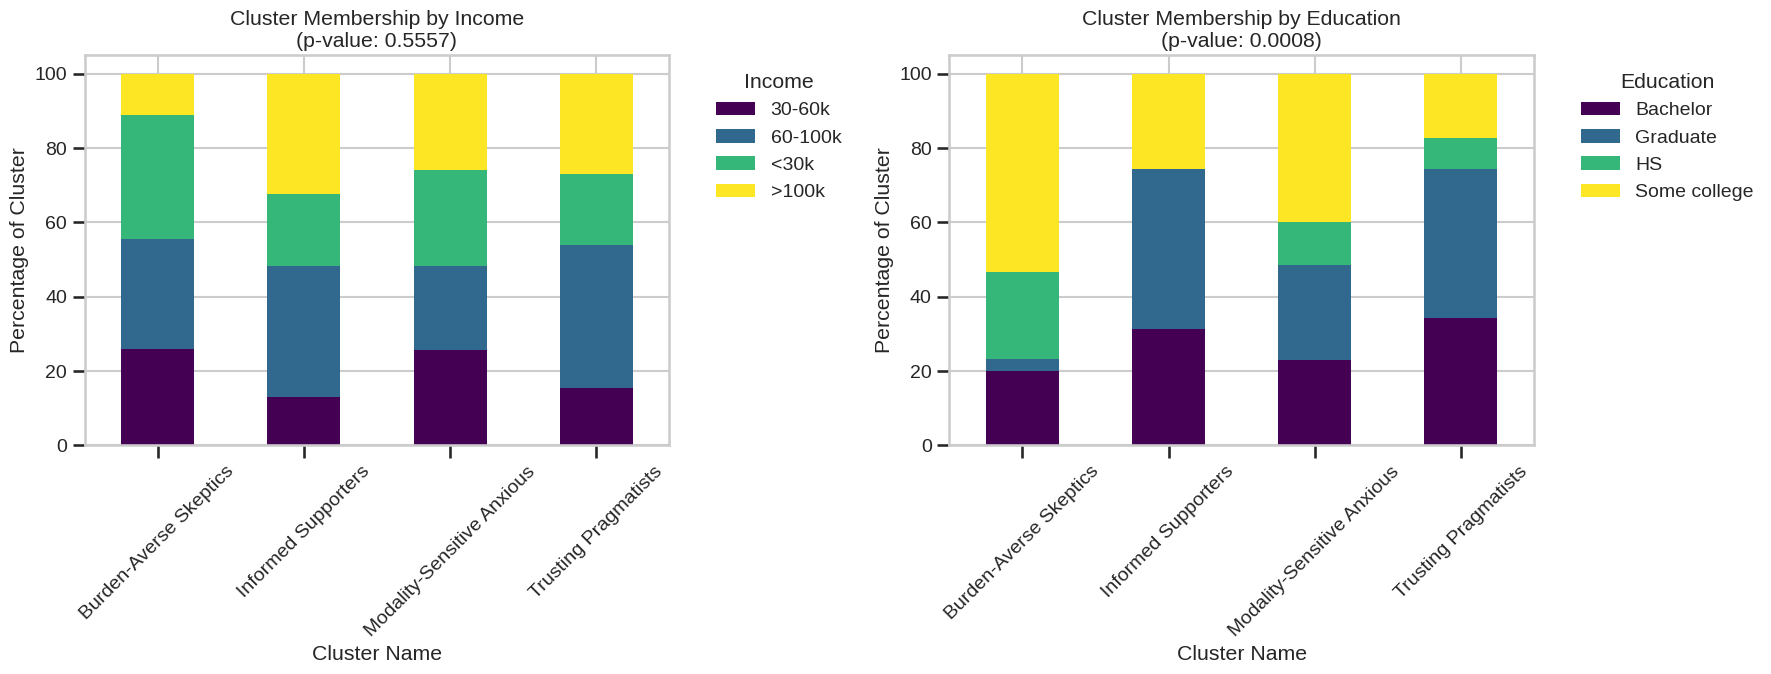

### Demographic Correlation Analysis Results

,Variable,Chi-square,p-value
0,income,7.7875,0.5557
1,education,28.5057,0.0008


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import Markdown

# Ensuring cluster_name exists based on the most recent mapping logic
if 'cluster' in analysis_df.columns:
    # Using the name map logic consistent with previous steps
    analysis_df['cluster_name'] = analysis_df['cluster'].map(cluster_name_map)

# 1. Preparing data for Income and Education correlation
demo_vars = ['income', 'education']
results = []

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, var in enumerate(demo_vars):
    # Creating contingency table
    contingency = pd.crosstab(analysis_df['cluster_name'], analysis_df[var])

    # Running Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency)
    results.append({'Variable': var, 'Chi-square': chi2, 'p-value': p})

    # Visualization: Normalized Stacked Bar Chart
    contingency_pct = contingency.div(contingency.sum(1), axis=0) * 100
    contingency_pct.plot(kind='bar', stacked=True, ax=axes[i], cmap='viridis')

    axes[i].set_title(f'Cluster Membership by {var.capitalize()}\n(p-value: {p:.4f})')
    axes[i].set_ylabel('Percentage of Cluster')
    axes[i].set_xlabel('Cluster Name')
    axes[i].legend(title=var.capitalize(), bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

demo_stats_df = pd.DataFrame(results)
display(Markdown("### Demographic Correlation Analysis Results"))
display(demo_stats_df.round(4))

<Figure size 1600x800 with 0 Axes>

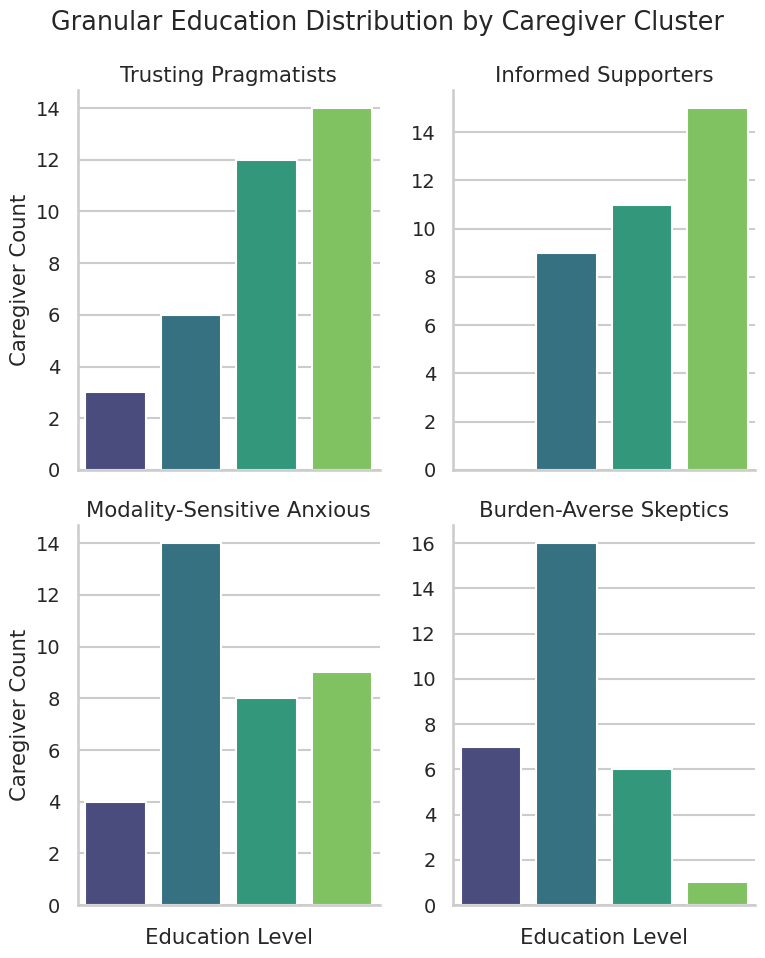

### Post-hoc Education Analysis: Percentage Breakdown

education,HS,Some college,Bachelor,Graduate
cluster_name,,,,
Burden-Averse Skeptics,23.330000,53.330000,20.000000,3.330000
Informed Supporters,0.000000,25.710000,31.430000,42.860000
Modality-Sensitive Anxious,11.430000,40.000000,22.860000,25.710000
Trusting Pragmatists,8.570000,17.140000,34.290000,40.000000



**Key Observations:**
- **Highest Academic Attainment:** The **Informed Supporters** cluster has the highest proportion of Graduate degree holders (42.9%).
- **Lower Relative Attainment:** The **Burden-Averse Skeptics** cluster shows the highest representation of caregivers with HS-level education (23.3%).


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

# 1. Post-hoc Education Distribution Analysis
education_order = ['HS', 'Some college', 'Bachelor', 'Graduate']

# Calculating detailed percentages
education_comparison = (
    pd.crosstab(analysis_df['cluster_name'], analysis_df['education'], normalize='index') * 100
).reindex(columns=education_order)

# 2. Visualization: Faceted Comparison
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Creating a long-form version for easier plotting
plot_df = analysis_df.copy()
plot_df['education'] = pd.Categorical(plot_df['education'], categories=education_order, ordered=True)

g = sns.catplot(
    data=plot_df,
    x='education',
    col='cluster_name',
    kind='count',
    palette='viridis',
    height=5,
    aspect=0.8,
    col_wrap=2,
    sharey=False
)

g.set_axis_labels("Education Level", "Caregiver Count")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Granular Education Distribution by Caregiver Cluster')

plt.show()

display(Markdown("### Post-hoc Education Analysis: Percentage Breakdown"))
display(education_comparison.round(2).style.background_gradient(cmap='YlGnBu', axis=1))

graduate_top = education_comparison['Graduate'].idxmax()
hs_top = education_comparison['HS'].idxmax()

display(Markdown(f"""
**Key Observations:**
- **Highest Academic Attainment:** The **{graduate_top}** cluster has the highest proportion of Graduate degree holders ({education_comparison.loc[graduate_top, 'Graduate']:.1f}%).
- **Lower Relative Attainment:** The **{hs_top}** cluster shows the highest representation of caregivers with HS-level education ({education_comparison.loc[hs_top, 'HS']:.1f}%).
"""))

## Using this notebook with the real REDCap export

To improvise the notebook I will now:
- Replace the synthetic data generation cell with the cleaned REDCap import.
- Keep the score construction and recoding logic exactly aligned with the instrument codebook.
- Upgrade the simple median imputation step to a study-approved MICE workflow where missingness is substantial or structurally informative.
- Revisit the final cluster names with the research team after seeing the real centroids and demographic profile tables.
- Compare this K-means solution against a follow-up Gaussian mixture or latent class analysis if the publication plan needs a stronger probabilistic framing.

In [19]:
# @title 📊 Caregiver Cluster Analysis Dashboard {display-mode: "form"}

import json
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from IPython.display import HTML
from google.colab import output

# --- 0. Dependency Logic (Clustering) ---
X = analysis_df[cluster_feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K_FINAL = 4
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=40)
analysis_df['cluster'] = kmeans_final.fit_predict(X_scaled)

# Profile Summarization
cluster_profiles = analysis_df.groupby('cluster')[cluster_feature_cols].mean()
cluster_profiles['overall_acceptance'] = cluster_profiles[['tfa_mri', 'tfa_eeg', 'tfa_blood', 'tfa_video', 'tfa_saliva', 'tfa_observe']].mean(axis=1)
cluster_profiles['invasive_acceptance'] = cluster_profiles[['tfa_mri', 'tfa_eeg', 'tfa_blood']].mean(axis=1)
cluster_profiles['noninvasive_acceptance'] = cluster_profiles[['tfa_video', 'tfa_saliva', 'tfa_observe']].mean(axis=1)
cluster_profiles['knowledge_mean'] = cluster_profiles[knowledge_score_var]

# Naming Logic
cluster_name_map = {
    cluster_profiles['overall_acceptance'].idxmax(): 'Trusting Pragmatists',
    cluster_profiles['overall_acceptance'].idxmin(): 'Burden-Averse Skeptics',
    cluster_profiles['knowledge_mean'].idxmax(): 'Informed Supporters'
}
remaining = [i for i in range(K_FINAL) if i not in cluster_name_map]
if remaining: cluster_name_map[remaining[0]] = 'Modality-Sensitive Anxious'

analysis_df['cluster_name'] = analysis_df['cluster'].map(cluster_name_map)

cluster_profiles_named = cluster_profiles.copy()
cluster_profiles_named.index = cluster_profiles_named.index.map(cluster_name_map)
cluster_summary = cluster_profiles_named[['overall_acceptance', 'invasive_acceptance', 'noninvasive_acceptance', 'knowledge_mean']].copy()
cluster_summary['n'] = analysis_df['cluster_name'].value_counts()
cluster_summary['pct'] = (cluster_summary['n'] / len(analysis_df) * 100).round(1)
cluster_summary.index.name = 'cluster_name'

# --- 1. Data Preparation for Dashboard ---
kpi_data = cluster_summary.reset_index().to_dict(orient='records')

# Radar Chart Data (Modalities)
radar_vars = ['tfa_mri', 'tfa_blood', 'tfa_video', 'tfa_observe', 'tfa_believe_positive', 'tfa_regret_reverse']
radar_json = {
    'labels': ['MRI', 'Blood', 'Video', 'Observe', 'Belief', 'Low Regret'],
    'datasets': []
}

colors = {
    'Trusting Pragmatists': 'rgba(31, 119, 180, 0.7)',
    'Modality-Sensitive Anxious': 'rgba(255, 127, 14, 0.7)',
    'Burden-Averse Skeptics': 'rgba(214, 39, 40, 0.7)',
    'Informed Supporters': 'rgba(44, 160, 44, 0.7)'
}

for cluster in cluster_summary.index:
    radar_json['datasets'].append({
        'label': cluster,
        'data': cluster_profiles_named.loc[cluster, radar_vars].tolist(),
        'borderColor': colors[cluster].replace('0.7', '1'),
        'backgroundColor': colors[cluster]
    })

# Correlation Matrix Data
corr_vars = ['tfa_mri', 'tfa_blood', 'tfa_video', 'tfa_observe', 'tfa_believe_positive', 'tfa_regret_reverse', 'autism_knowledge_score']
corr_matrix = analysis_df[corr_vars].corr().values.tolist()
corr_json = {
    'labels': ['MRI', 'Blood', 'Video', 'Observe', 'Belief', 'Regret(R)', 'Knowledge'],
    'values': corr_matrix
}

# Modality Contrast Bar Data
modality_json = {
    'labels': cluster_summary.index.tolist(),
    'invasive': cluster_summary['invasive_acceptance'].tolist(),
    'noninvasive': cluster_summary['noninvasive_acceptance'].tolist()
}

# --- 2. Dashboard HTML/JS ---
html_string = """
<!DOCTYPE html>
<html>
<head>
    <script src=\"https://cdn.jsdelivr.net/npm/chart.js\"></script>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background: #f4f6f8; color: #1a1a1a; padding: 20px; margin: 0; }
        .dashboard-container { max-width: 1400px; margin: auto; display: flex; flex-direction: column; gap: 20px; }
        .kpi-row { display: grid; grid-template-columns: repeat(auto-fit, minmax(240px, 1fr)); gap: 20px; }
        .card { background: white; padding: 20px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.08); display: flex; flex-direction: column; min-height: 0; }
        .kpi-card { border-top: 4px solid #2980b9; }
        .kpi-title { font-size: 0.85rem; color: #2c3e50; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px; }
        .kpi-value { font-size: 2rem; font-weight: 800; margin: 10px 0; color: #1a1a1a; }
        .main-row { display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 20px; height: 420px; }
        .canvas-wrapper { position: relative; flex-grow: 1; min-height: 0; width: 100%; }
        h2 { font-size: 1.1rem; margin-top: 0; margin-bottom: 10px; color: #1a1a1a; font-weight: 700; }
        table { width: 100%; border-collapse: collapse; margin-top: 10px; color: #1a1a1a; }
        th { background: #f8f9fa; font-size: 0.85rem; text-align: left; padding: 12px; color: #2c3e50; border-bottom: 2px solid #eee; }
        td { padding: 12px; border-bottom: 1px solid #eee; font-size: 0.95rem; }
        tr:hover { background-color: #fcfcfc; }
    </style>
</head>
<body>
    <div class="dashboard-container">
        <div class="kpi-row" id="kpi-row"></div>
        <div class="main-row">
            <div class="card">
                <h2>Modality Profiles (Radar)</h2>
                <div class="canvas-wrapper"><canvas id="radarChart"></canvas></div>
            </div>
            <div class="card">
                <h2>Feature Correlations</h2>
                <div class="canvas-wrapper"><canvas id="corrChart"></canvas></div>
            </div>
            <div class="card">
                <h2>Acceptance Contrast</h2>
                <div class="canvas-wrapper"><canvas id="modalityChart"></canvas></div>
            </div>
        </div>
        <div class="card">
            <h2>Full Cluster Metrics Analysis</h2>
            <div style="overflow-x: auto;">
                <table>
                    <thead><tr><th>Cluster Profile</th><th>N</th><th>Sample %</th><th>Acceptance</th><th>Knowledge</th></tr></thead>
                    <tbody id="table-body"></tbody>
                </table>
            </div>
        </div>
    </div>
    <script>
        const radarData = DATA_RADAR;
        const kpiData = DATA_KPI;
        const modalityData = DATA_MODALITY;
        const corrData = DATA_CORR;

        const kpiRow = document.getElementById('kpi-row');
        const tableBody = document.getElementById('table-body');

        kpiData.forEach(d => {
            kpiRow.innerHTML += `
                <div class="card kpi-card">
                    <div class="kpi-title">${d.cluster_name}</div>
                    <div class="kpi-value">n = ${d.n}</div>
                    <div style="font-size: 0.9rem; font-weight: 500; color: #34495e">Avg Accept: ${d.overall_acceptance.toFixed(2)}</div>
                </div>`;
            tableBody.innerHTML += `
                <tr>
                    <td><strong>${d.cluster_name}</strong></td>
                    <td>${d.n}</td>
                    <td>${d.pct}%</td>
                    <td>${d.overall_acceptance.toFixed(2)}</td>
                    <td>${d.knowledge_mean.toFixed(2)}</td>
                </tr>`;
        });

        // Radar Chart
        new Chart(document.getElementById('radarChart'), {
            type: 'radar',
            data: radarData,
            options: {
                responsive: true, maintainAspectRatio: false,
                plugins: { legend: { display: false } },
                scales: { r: { min: 1, max: 7, ticks: { display: false } } }
            }
        });

        // Heatmap Helper
        function createHeatmap(elementId, xLabels, yLabels, values, colorScale) {
            const points = [];
            yLabels.forEach((y, yIdx) => {
                xLabels.forEach((x, xIdx) => {
                    points.push({ x: xIdx, y: yIdx, v: values[yIdx][xIdx] });
                });
            });

            new Chart(document.getElementById(elementId), {
                type: 'bubble',
                data: {
                    datasets: [{
                        data: points.map(p => ({x: p.x, y: p.y, r: 15})),
                        backgroundColor(ctx) {
                            const val = points[ctx.dataIndex].v;
                            return colorScale(val);
                        }
                    }]
                },
                options: {
                    responsive: true, maintainAspectRatio: false,
                    plugins: {
                        legend: false,
                        tooltip: { callbacks: { label: (ctx) => `${xLabels[points[ctx.dataIndex].x]}: ${points[ctx.dataIndex].v.toFixed(2)}` } }
                    },
                    scales: {
                        x: { ticks: { callback: v => xLabels[v], color: '#1a1a1a', font: {size: 8} }, grid: {display: false} },
                        y: { ticks: { callback: v => yLabels[v], color: '#1a1a1a', font: {size: 8} }, grid: {display: false} }
                    }
                }
            });
        }

        createHeatmap('corrChart', corrData.labels, [...corrData.labels].reverse(), [...corrData.values].reverse(), (v) => v > 0 ? `rgba(52, 152, 219, ${v})` : `rgba(231, 76, 60, ${Math.abs(v)})`);

        new Chart(document.getElementById('modalityChart'), {
            type: 'bar', data: { labels: modalityData.labels, datasets: [
                { label: 'Invasive', data: modalityData.invasive, backgroundColor: '#c0392b' },
                { label: 'Non-Invasive', data: modalityData.noninvasive, backgroundColor: '#2980b9' }
            ]},
            options: { responsive: true, maintainAspectRatio: false, indexAxis: 'y',
            plugins: { legend: { labels: { color: '#1a1a1a', font: {weight: '600', size: 9} } } },
            scales: { x: { min: 0, max: 7, ticks: { color: '#1a1a1a' } }, y: { ticks: { color: '#1a1a1a', font: {size: 8} } } } }
        });
    </script>
</body>
</html>
""".replace('DATA_RADAR', json.dumps(radar_json)).replace('DATA_KPI', json.dumps(kpi_data)).replace('DATA_MODALITY', json.dumps(modality_json)).replace('DATA_CORR', json.dumps(corr_json))

display(HTML(html_string))

Cluster Profile,N,Sample %,Acceptance,Knowledge


In [18]:
!pip install -q scikit-posthocs

from scipy.stats import kruskal
import scikit_posthocs as sp
from IPython.display import Markdown, display

# Define cluster order for consistent analysis
cluster_order = [
    'Trusting Pragmatists',
    'Modality-Sensitive Anxious',
    'Burden-Averse Skeptics',
    'Informed Supporters',
]

# 1. Kruskal-Wallis H-test
groups = [analysis_df[analysis_df['cluster_name'] == name][knowledge_score_var] for name in cluster_order]
h_stat, p_val = kruskal(*groups)

# 2. Post-hoc Conover test for pairwise comparisons (replaces the incorrect Nemenyi call)
posthoc = sp.posthoc_conover(analysis_df, val_col=knowledge_score_var, group_col='cluster_name', p_adjust='holm')

print(f'Kruskal-Wallis H-statistic: {h_stat:.4f}')
print(f'p-value: {p_val:.4g}')

display(Markdown('### Pairwise Post-hoc Comparisons (p-values)'))
display(posthoc.style.background_gradient(cmap='Reds', vmin=0, vmax=0.05))

Kruskal-Wallis H-statistic: 53.6779
p-value: 1.314e-11


### Pairwise Post-hoc Comparisons (p-values)

,Burden-Averse Skeptics,Informed Supporters,Modality-Sensitive Anxious,Trusting Pragmatists
Burden-Averse Skeptics,1.000000,0.000000,0.000046,0.000000
Informed Supporters,0.000000,1.000000,0.000038,0.038553
Modality-Sensitive Anxious,0.000046,0.000038,1.000000,0.026031
Trusting Pragmatists,0.000000,0.038553,0.026031,1.000000
